In [1]:
from pathlib import Path
import sys
import traceback
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.axes import Axes
import spikeinterface as si 
import cv2
import data_analysis.mea_analysis as mea
SAMPLING_RATE = mea.SAMPLING_RATE




In [2]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

In [3]:
def propagation_plot(indices_to_plot: list, 
                     axes: Axes, 
                     org_img: np.ndarray, 
                     filtered_first_spikes : list,
                     filtered_chans : list):
    for i, j in enumerate(indices_to_plot):
        
        st = filtered_first_spikes[j]
        chans = filtered_chans[j].copy()
        heatmap = np.full(4096, np.nan)
        heatmap[chans] = st
        heatmap = heatmap.reshape(64,64)
        org_img_shape = org_img.shape[:2]
        heatmap = cv2.resize(heatmap,org_img_shape, interpolation=cv2.INTER_NEAREST)
        axes[i].imshow(org_img)
        axes[i].imshow(heatmap)
        axes[i].set_axis_off()

        cbar = plt.colorbar(axes[i].images[1], ax=axes[i], shrink=0.5, pad=0.01)
        cbar.set_label("First spike time [s]", rotation=270, labelpad=15)


In [4]:
origins = []
org_imgs = []
filtered_first_spikes_list = []
filtered_chans_list = []

for i, row in tqdm(df_overview.iterrows()):
    
    st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])
    burst_json_path = Path(row["folder_path"]) / "burst_params.json"
    sles = np.load(row["sle_path"])
    image_path = Path(row["folder_path"]) / Path("org_image.png")
    org_img = cv2.imread(image_path)
    org_img = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)
    
    #estimate sle origin and and filter spike sorted data
    res = mea.filter_spikes_find_origin(sles=sles,
                                                st=st,
                                                clu=clu,
                                                cluster_to_channel_map=vectorized_map, 
                                                burst_json_path=burst_json_path, 
                                                folder_path=row["folder_path"])
    estimated_SLE_orgins, first_spikes, unique_chans_list, filtered_first_spikes, filtered_chans, chan_subsets = res
    origins.append(estimated_SLE_orgins)
    org_imgs.append(org_img)
    filtered_first_spikes_list.append(filtered_first_spikes)
    filtered_chans_list.append(filtered_chans)
    continue
    fig, ax = plt.subplots(2,2, figsize=(10,10), dpi=300)
    print(row["folder"])
    print(i)
    ax = ax.flatten()
    img = org_img.copy()
    #img = cv2.resize(img, (64,64))
    
    propagation_plot(indices_to_plot=[1,2,3,4],
                     axes=ax,
                     org_img=org_img,
                     filtered_first_spikes=filtered_first_spikes,
                     filtered_chans=filtered_chans)

    plt.show()
    

0it [00:00, ?it/s]/home/ferdinand-forberger/.conda/envs/rapids-25.04/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1746251341172/work/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------


100%|██████████| 408/408 [00:00<00:00, 2138.67it/s]
1it [00:04,  4.20s/it]

Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


100%|██████████| 554/554 [00:00<00:00, 1098.45it/s]
2it [00:09,  4.60s/it]

...

100%|██████████| 558/558 [00:00<00:00, 1182.35it/s]
20it [02:26,  8.00s/it]

Comparison of Labels (Original vs. Changed)
KSLabel agreement: 450, disagreement: 0
Number of good clusters (Original): 91
Number of good clusters (Changed): 91
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 450, disagreement: 0
Number of good clusters (Original): 91
Number of good clusters (Changed): 91
-------------------------------------------------------


100%|██████████| 450/450 [00:00<00:00, 746.80it/s]
21it [02:32,  7.52s/it]

Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------


100%|██████████| 323/323 [00:00<00:00, 806.02it/s]
22it [02:38,  7.18s/it]


In [5]:
from data_analysis.plotting import get_c_map_colors
colors = get_c_map_colors()

In [6]:
import matplotlib.gridspec as gridspec

In [6]:
sles = np.load(row["sle_path"])

In [7]:
def single_propagation_plot(idx_to_plot: list, 
                     ax: Axes, 
                     org_img: np.ndarray, 
                     filtered_first_spikes : list,
                     filtered_chans : list,
                     origins: list,
                     *args,
                     **kwargs):

    st = filtered_first_spikes[idx_to_plot]
    assert isinstance(origins, np.ndarray), "origins is not a list"
    print(f"origins: {origins.shape}")
    assert len(origins) == len(filtered_first_spikes), "origins and filtered_first_spikes have different lengths"
    origin = origins[idx_to_plot,:].copy()
    origin = origin[np.newaxis,:]
    assert origin.shape[0] == 1, "The first dim must be 1"
    assert origin.shape[1] == 2, "The second dim must be 2"
    
    assert isinstance(origin, np.ndarray), "origin is not a numpy array"

    print(np.max(st))
    chans = filtered_chans[idx_to_plot].copy()
    heatmap = np.full(4096, np.nan)
    heatmap[chans] = st
    heatmap = heatmap.reshape(64,64)
    org_img_shape = org_img.shape[:2]
    heatmap = cv2.resize(heatmap,org_img_shape, interpolation=cv2.INTER_NEAREST)
    ax.imshow(org_img)
    hm = ax.imshow(heatmap, *args, **kwargs)
    print(f"orgin: {origin}")
    origin = mea.to_img_coord(org_img, origin[:,0], origin[:,1])
    ax.scatter(origin[0], origin[1], alpha=1, color="white",s=25, marker="*")
    ax.set_axis_off()
    return hm

In [8]:
sle = np.load("/media/ferdinand-forberger/Seagate Portable Drive/8561_5/sle.npy")
sle = sle/SAMPLING_RATE
np.where((sle>497)&(sle<500))
org_img_path = Path("/media/ferdinand-forberger/RawDataBackUp/8561_5/org_image.png")
org_img = cv2.imread(org_img_path)
org_img = cv2.cvtColor(org_img, cv2.COLOR_BGR2RGB)


In [9]:
def calculate_COAT(st_event,chans_event):
    x, y = mea.chans_to_coords(chans_event)
    d_idx = 700
    overlap_idx = 500
    start_frame = st_event[0]
    end_frame = st_event[-1]

    start_frames = np.arange(start_frame, end_frame, (d_idx-overlap_idx))
    COAT = []
    for start_frame in start_frames:
        end_frame = start_frame + d_idx
        time_mask = (st_event >= start_frame) & (st_event < end_frame)
        st_loc = st_event[time_mask]
        chan_loc = chans_event[time_mask]
        a = [np.sum(chan_loc == chan)/(end_frame-start_frame) for chan in np.unique(chan_loc)]
        a = np.array(a)
        x_loc, y_loc = mea.chans_to_coords(np.unique(chan_loc))
        coa = mea.calculate_center_of_activity_2d(a, x_loc, y_loc)
        COAT.append(coa)
    COAT = np.array(COAT)
    return COAT

In [10]:
def calculate_COAT_wrapper(st : np.ndarray, chans: np.ndarray, sle_start:int, sle_end:int):
    st_event = st[(st>=sle_start)&(st<=sle_end)]
    chans_event = chans[(st>=sle_start)&(st<=sle_end)]
    COAT = calculate_COAT(st_event, chans_event)
    return COAT


In [11]:
from joblib import Parallel, delayed

In [12]:
rec_num = 1

In [13]:
n_jobs = 8
sles = np.load(df_overview["sle_path"][rec_num])
sle_starts = sles[0,:]
sle_ends = sles[1,:]
st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(df_overview["folder_path"][rec_num])
#SOATs = Parallel(n_jobs=n_jobs)(delayed(calculate_COAT_wrapper)(st, best_cha_st, sle_start, sle_end) for sle_start, sle_end in zip(sle_starts, sle_ends))
SOATs = []
for sle_start, sle_end in zip(sle_starts, sle_ends):
    COAT = calculate_COAT_wrapper(st, best_cha_st, sle_start, sle_end)
    SOATs.append(COAT)

Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


In [14]:
channel_wise_activity = np.zeros(4096)
for i in range(4096):
    channel_mask =  best_cha_st == i
    channel_wise_activity[i] = len(st[channel_mask])
channel_wise_activity = channel_wise_activity.reshape(64,64)
channel_wise_activity = channel_wise_activity/600
channel_wise_activity[channel_wise_activity<1] = np.nan

In [16]:
acitivity_map = cv2.resize(channel_wise_activity, (org_img.shape[1], org_img.shape[0]), interpolation=cv2.INTER_NEAREST)

In [15]:
from data_analysis.loading_and_saving import get_rec_obj

In [17]:
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")

In [18]:
durs = []
rates = []
for i, row in df_overview.iterrows():
    recording = get_rec_obj(row["bin_path_x"])
    recording_dur = recording.get_duration()
    sle = np.load(row["sle_path"])
    durs.append(np.mean(sle[1,:] - sle[0,:])/SAMPLING_RATE)
    rates.append(sle.shape[1]/recording_dur)
df_overview["sle_dur"] = durs
df_overview["sle_rate"] = rates

In [19]:
df_overview = df_overview.sort_values(by="group", ascending=True)
save_path = "data/dur_metrics.xlsx"
df_overview.to_excel(save_path)

In [20]:
def plot_arrow_head(x: np.ndarray, y: np.ndarray, ax: Axes, loc_idx0:int, loc_idx1:int, **kwargs) -> None:
    """
    Plots an arrowhead at the end of a line defined by x and y coordinates.
    All keyword arguments are passed directly to ax.arrow.
    """
    x_start = x[loc_idx0]
    y_start = y[loc_idx0]
    dx = x[loc_idx1] - x_start
    dy = y[loc_idx1] - y_start

    ax.arrow(
        x_start,
        y_start,
        dx,
        dy,
        **kwargs
    )

In [21]:
from scipy.stats import mannwhitneyu

/tmp/ipykernel_61457/2908509441.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_dur.set_xticklabels(["Sham","Glioma"], rotation=90)


Median SLE duration Sham: 0.85 s, Tumor: 0.41 s, Fold change: 0.48
MWU p-value: 0.00110


/tmp/ipykernel_61457/2908509441.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_rate.set_xticklabels(["Sham","Glioma"], rotation=90)


Median SLE rate Sham: 0.16 s, Tumor: 0.18 s, Fold change: 1.11
MWU p-value: 0.973692
origins: (75, 2)
0.1332909759240124
orgin: [[16.5 32.5]]
origins: (75, 2)
0.15688140310994925
orgin: [[15.33333333  9.88888889]]


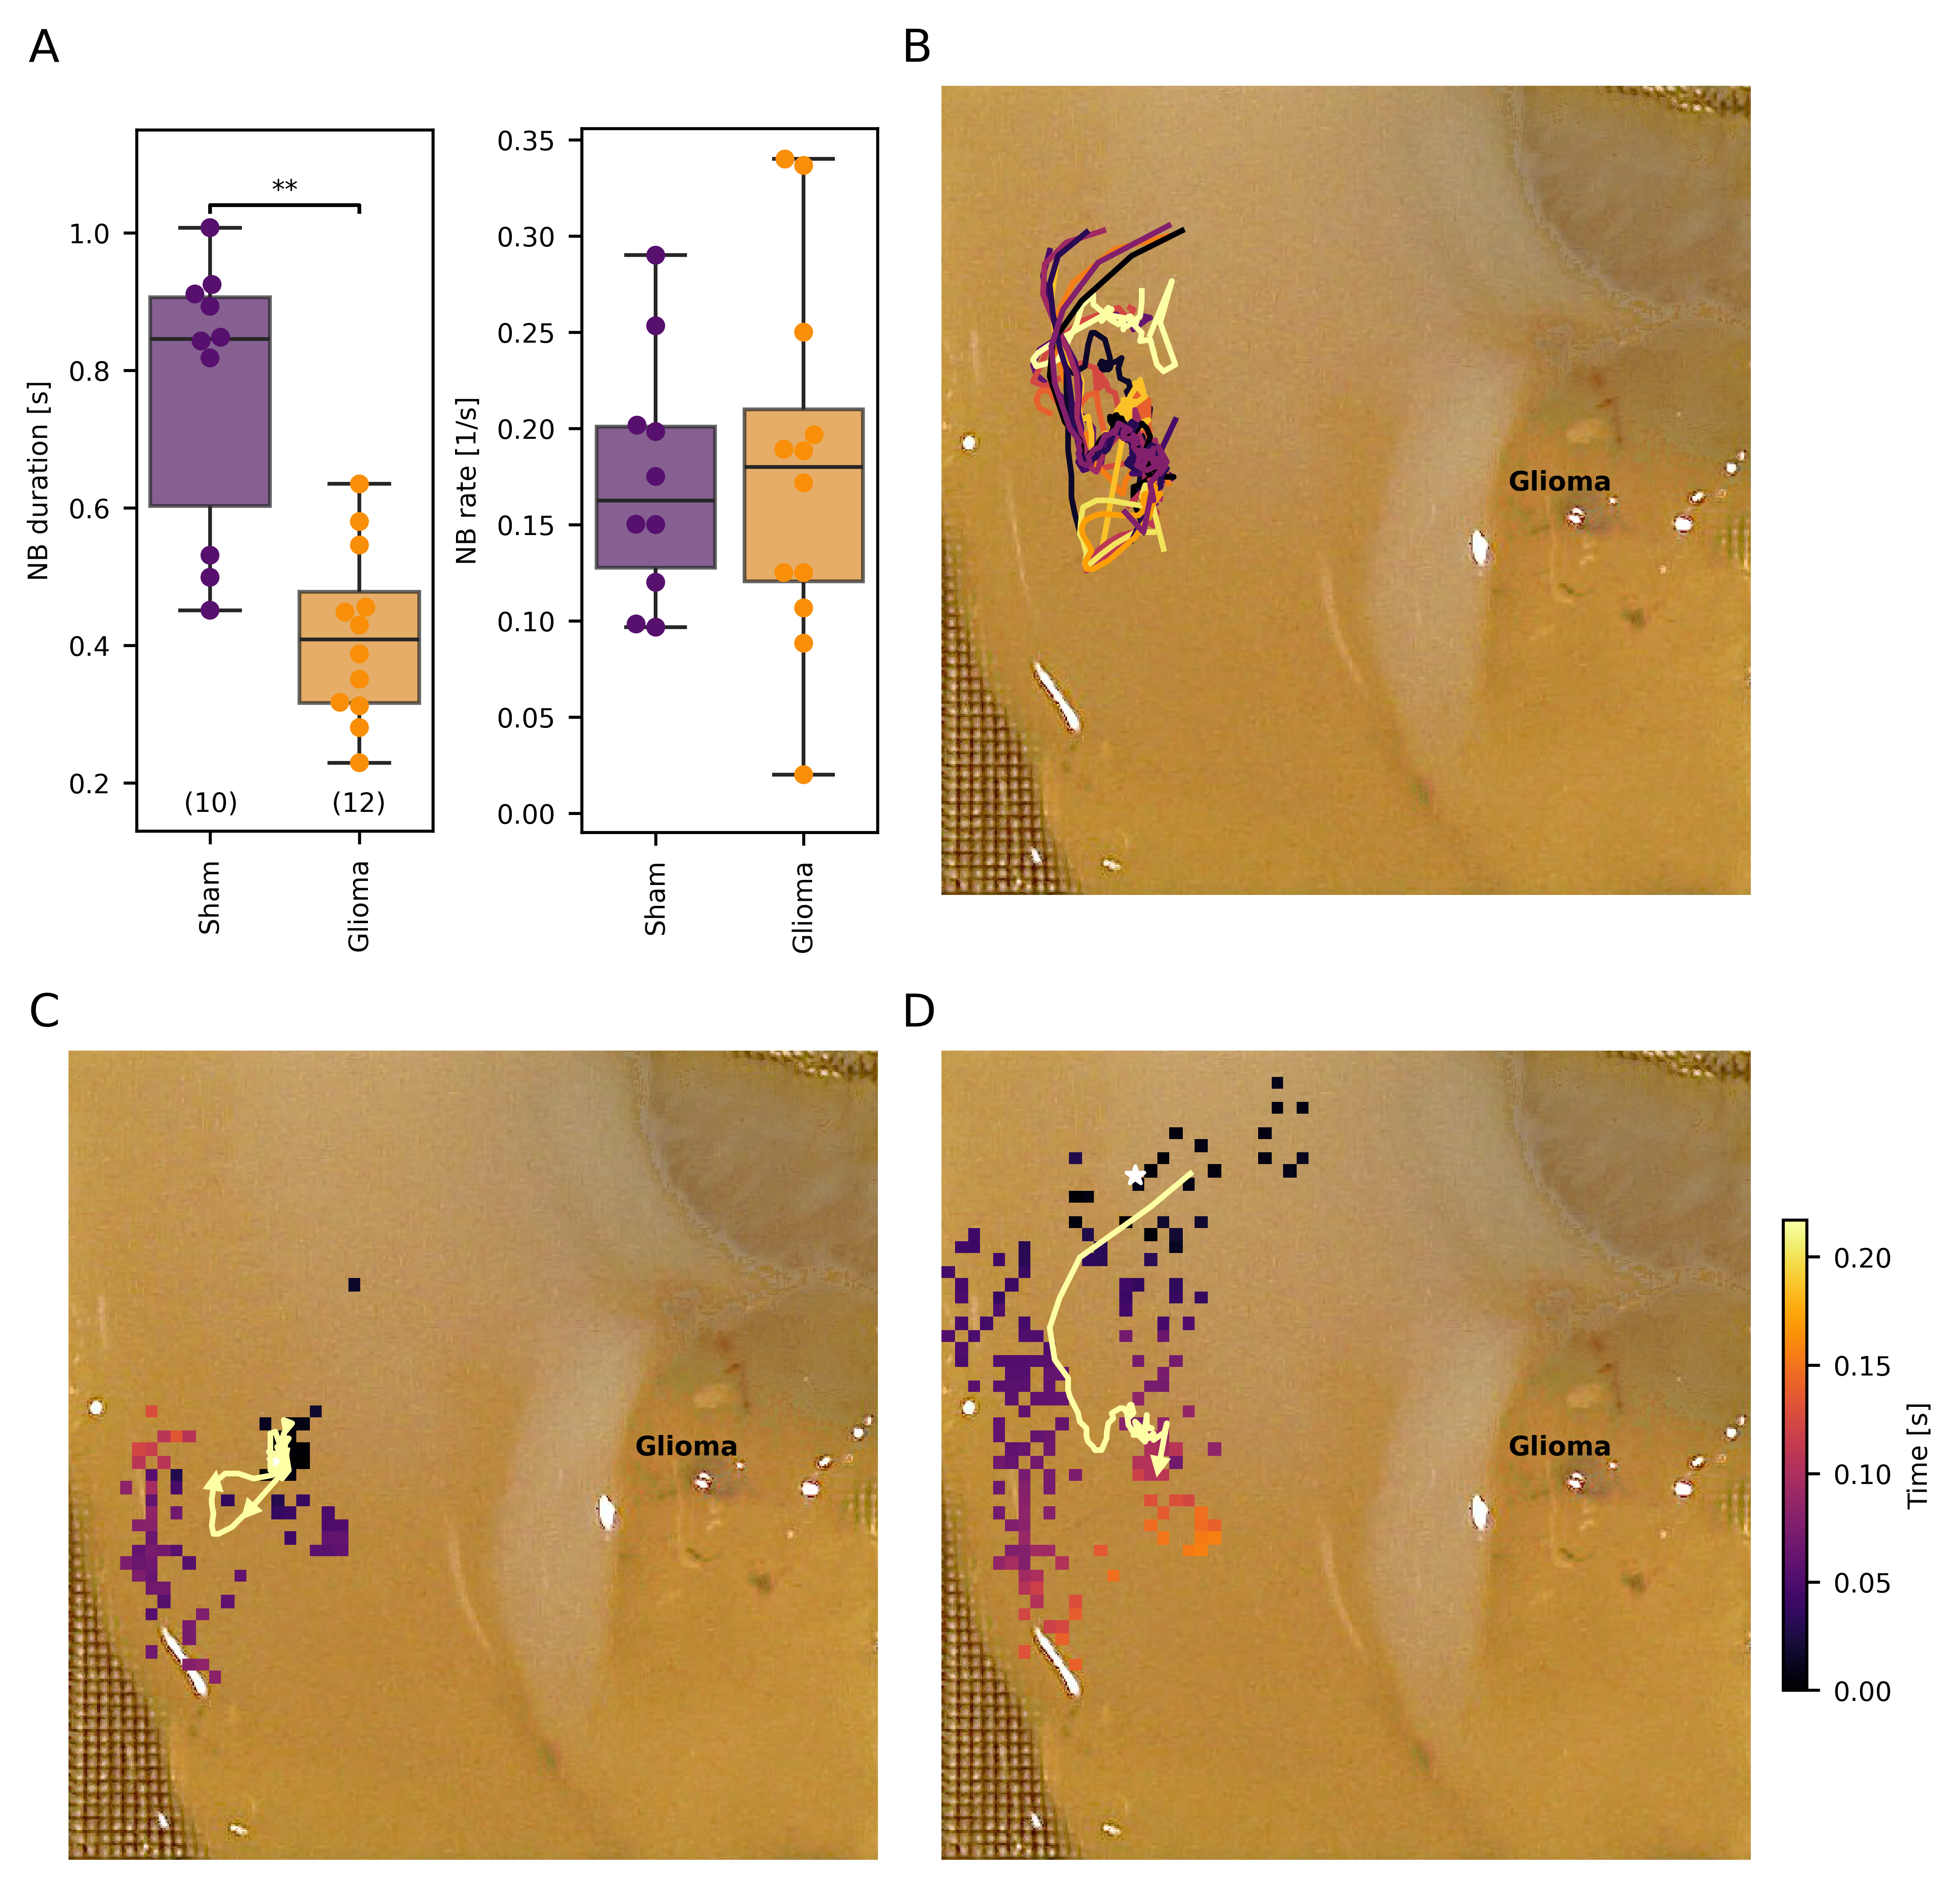

In [24]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

cm=1/2.54
fig_width_cm = 18
fig_height_cm = 18

fig = plt.figure(figsize=(fig_width_cm*cm, fig_height_cm*cm),
                 dpi=600, layout="constrained")
plt.rcParams.update({'font.size': 7})

gs = GridSpec(nrows=2, ncols=2, figure=fig,
              height_ratios=[1,1]) 
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0]) 
ax4 = fig.add_subplot(gs[1, 1])

gs00 = gs[0,0].subgridspec(nrows=1, ncols=2)
ax_dur = fig.add_subplot(gs00[0, 0])
ax_rate = fig.add_subplot(gs00[0, 1])

boxplotcolors = get_c_map_colors()

#################################################################################
sns.boxplot(data=df_overview, x="group", y="sle_dur", ax=ax_dur, hue="group", 
            palette=[boxplotcolors[1], boxplotcolors[3]],boxprops={'alpha': 0.7}, zorder=0)
sns.swarmplot(data=df_overview, x="group", y="sle_dur", ax=ax_dur, hue="group",
             palette=[boxplotcolors[1], boxplotcolors[3]], dodge=False, alpha=1, edgecolor="black", linewidth=0, zorder=1)
#significane bar
ax_dur.plot([0,0,1,1], [1.03,1.04, 1.04, 1.03], color="black", linewidth=1)
ax_dur.text(0.5, 1.042, "**", ha="center", va="bottom", color="black")
ax_dur.set_ylim(0.13,1.15)

ax_dur.set_xlabel("")
ax_dur.set_ylabel("NB duration [s]")
ax_dur.set_xticklabels(["Sham","Glioma"], rotation=90)
# vals
median_sham = df_overview[df_overview["group"]=="Sham"]["sle_dur"].median()
median_tumor = df_overview[df_overview["group"]=="Tumor"]["sle_dur"].median()
print(f"Median SLE duration Sham: {median_sham:.2f} s, Tumor: {median_tumor:.2f} s, Fold change: {median_tumor/median_sham:.2f}")
mwu_res = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["sle_dur"],
                       df_overview[df_overview["group"]=="Tumor"]["sle_dur"],
                       alternative="two-sided")
print(f"MWU p-value: {mwu_res.pvalue:.5f}")

#################################################################################
sns.boxplot(data=df_overview, x="group", y="sle_rate", ax=ax_rate, hue="group", 
            palette=[boxplotcolors[1], boxplotcolors[3]], boxprops={"alpha" : 0.7}, zorder=0)
sns.swarmplot(data=df_overview, x="group", y="sle_rate", ax=ax_rate, hue="group",
             palette=[boxplotcolors[1], boxplotcolors[3]], dodge=False, alpha=1, edgecolor="black", linewidth=0, zorder=1)
ax_rate.set_xlabel("")
ax_rate.set_ylabel("NB rate [1/s]")
ax_rate.set_xticklabels(["Sham","Glioma"], rotation=90)
#numbers
ax_dur.text(1/4, 0.02, s=f"({len(df_overview[df_overview["group"]=="Sham"])})",
             horizontalalignment="center",
             verticalalignment="bottom",
             transform=ax_dur.transAxes)
ax_dur.text(3/4, 0.02, s=f"({len(df_overview[df_overview["group"]=="Tumor"])})", 
            horizontalalignment="center",
            verticalalignment="bottom",
            transform=ax_dur.transAxes)

ax_rate.set_ylim(-0.01,None)

#vals
median_sham = df_overview[df_overview["group"]=="Sham"]["sle_rate"].median()
median_tumor = df_overview[df_overview["group"]=="Tumor"]["sle_rate"].median()
print(f"Median SLE rate Sham: {median_sham:.2f} s, Tumor: {median_tumor:.2f} s, Fold change: {median_tumor/median_sham:.2f}")
mwu_res = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["sle_rate"],
                       df_overview[df_overview["group"]=="Tumor"]["sle_rate"],
                       alternative="two-sided")
print(f"MWU p-value: {mwu_res.pvalue:.6f}")

#################################################################################
ax2.imshow(org_img)

num_soats_to_plot = 15 #min(20, len(SOATs) - 30) if len(SOATs) > 30 else 0
colors = get_c_map_colors(num_soats_to_plot)

rng = np.random.default_rng(42)
for i, SOAT_item in enumerate(SOATs[30 : 30 + num_soats_to_plot]):
    x_traj, y_traj = mea.to_img_coord(img=org_img, x=SOAT_item[:,0], y=SOAT_item[:,1])
    zorder = rng.uniform(0, num_soats_to_plot)
    ax2.plot(x_traj, y_traj, color=colors[i], zorder=zorder)
    #plot_arrow_head(x=x_traj,y=y_traj,ax=ax2,loc_idx0=3,loc_idx1=4, zorder=zorder, head_width=9, head_length=9, fc=colors[i], ec=colors[i]) just look messy


#################################################################################
vmin = 0
vmax = 0.217
hm_ax3 = single_propagation_plot(idx_to_plot=61,
                                 ax=ax3,
                                 org_img=org_img,
                                 filtered_first_spikes=filtered_first_spikes_list[rec_num],
                                 filtered_chans=filtered_chans_list[rec_num],
                                 origins=origins[rec_num],
                                 vmin=vmin,
                                 vmax=vmax,
                                 cmap="inferno")
SOAT_item = SOATs[61]
x_traj, y_traj = mea.to_img_coord(img=org_img, x=SOAT_item[:,0], y=SOAT_item[:,1])
colors = get_c_map_colors(20)
color = colors[19]
ax3.plot(x_traj, y_traj, color=color)
plot_arrow_head(x=x_traj,y=y_traj,ax=ax3,loc_idx0=3,loc_idx1=4, zorder=100, head_width=9, head_length=9, fc=color, ec=color)

plot_arrow_head(x=x_traj,y=y_traj,ax=ax3,loc_idx0=11,loc_idx1=12, zorder=100, head_width=9, head_length=9, fc=color, ec=color)

#################################################################################

idx_num = 4
hm_ax4 = single_propagation_plot(idx_to_plot=idx_num, 
                                 ax=ax4,
                                 org_img=org_img,
                                 filtered_first_spikes=filtered_first_spikes_list[rec_num],
                                 filtered_chans=filtered_chans_list[rec_num],
                                 origins=origins[rec_num],
                                 vmin=vmin,
                                 vmax=vmax,
                                 cmap="inferno")

#soat
SOAT_item = SOATs[idx_num]
x_traj, y_traj = mea.to_img_coord(img=org_img, x=SOAT_item[:,0], y=SOAT_item[:,1])

color = colors[19]
ax4.plot(x_traj, y_traj, color=color)
plot_arrow_head(x=x_traj,y=y_traj,ax=ax4, loc_idx0=-2,loc_idx1=-1, zorder=100, head_width=9, 
                head_length=9, fc=color, ec=color)



cbar4 = fig.colorbar(hm_ax4, ax=ax4, orientation='vertical', 
                     fraction=0.046, pad=0.04, shrink=0.5)
cbar4.set_label('Time [s]')
ax4.set_axis_off()

axes_list = [ax1, ax2, ax3, ax4]
letters = ["A", "B", "C", "D"]
ax1.set_axis_off()
for i, ax_item in enumerate(axes_list):
    ax_item.set_aspect('equal')
    ax_item.set_axis_off()
    ax_item.text(x=-0.05, y=1.03,s=letters[i], transform=ax_item.transAxes, fontsize=12) 
    if i==0:
        continue
    ax_item.text(x=0.7, y=0.5, s="Glioma", transform=ax_item.transAxes,fontweight="bold")
ax_dur.set_aspect(4.6)
ax_rate.set_aspect(13)
plt.savefig("plots/Figure_soat.png", dpi=600)
plt.show()